In [1]:
import rasterio
from rasterio.mask import mask
import osmnx as ox
import geopandas as gpd
from rasterio.features import shapes
from shapely.geometry import shape
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
os.chdir("..")

In [3]:
path_to_lcz = "data/lcz/lcz_v3.tif"
polygon = ox.geocode_to_gdf("Bamberg, Germany").iloc[0]["geometry"]

In [4]:
with rasterio.open(path_to_lcz) as src:
    out_image, out_transform = mask(src, [polygon], crop=True)
    band = out_image[0]

    if src.nodata is not None:
        valid_mask = band != src.nodata
    else:
        valid_mask = ~np.isnan(band)

    records = []
    for geom, value in shapes(band, mask=valid_mask, transform=out_transform):
        records.append({
            "geometry": shape(geom),
            "lcz_class": int(value)
        })

In [5]:
gdf_lcz = gpd.GeoDataFrame(records, crs=src.crs)

lcz_mapping = {
    1: "Compact highrise (1)", 2: "Compact midrise (2)", 3: "Compact lowrise (3)", 4: "Open highrise (4)", 5: "Open midrise (5)",
    6: "Open lowrise (6)", 7: "Lightweight lowrise (7)", 8: "Large lowrise (8)", 9: "Sparsely built (9)", 10: "Heavy Industry (10)",
    11: "Dense trees (A)", 12: "Scattered trees (B)", 13: "Bush, scrub (C)", 14: "Low plants (D)",
    15: "Bare rock or paved (E)", 16: "Bare soil or sand (F)", 17: "Water (G)"
}

gdf_lcz["lcz"] = gdf_lcz["lcz_class"].map(lcz_mapping)

gdf_lcz.head()

,geometry,lcz_class,lcz
0,"POLYGON ((10.91633 49.92836, 10.91633 49.92747...",12,Scattered trees (B)
1,"POLYGON ((10.91543 49.92836, 10.91543 49.92657...",9,Sparsely built (9)
2,"POLYGON ((10.91363 49.92747, 10.91363 49.92657...",12,Scattered trees (B)
3,"POLYGON ((10.91633 49.92747, 10.91633 49.92657...",6,Open lowrise (6)
4,"POLYGON ((10.91094 49.92657, 10.91094 49.92567...",9,Sparsely built (9)


<Axes: >

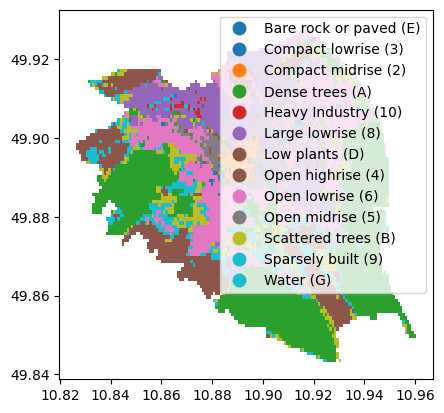

In [6]:
gdf_lcz.plot(column="lcz", legend=True)

In [7]:
gdf_hexagons = gpd.read_parquet("results/hexagon_grid_bamberg.parquet")

In [8]:
gdf_lcz = gdf_lcz.to_crs(gdf_hexagons.crs)

In [9]:
def get_dominant_lcz(hexagon):
    lcz_counts = gdf_lcz[gdf_lcz.geometry.intersects(hexagon)].lcz.value_counts()
    if not lcz_counts.empty:
        return lcz_counts.idxmax()
    else:
        return None

gdf_hexagons["lcz"] = gdf_hexagons.geometry.apply(lambda hexagon: get_dominant_lcz(hexagon))

In [10]:
gdf_hexagons.columns

Index(['geometry', 'average_time_bike_1', 'average_time_bike_2',
       'average_time_bike_20', 'average_time_bike_morning_vuln1_1',
       'average_time_bike_morning_vuln1_2',
       'average_time_bike_morning_vuln1_20',
       'average_time_bike_morning_vuln2_1',
       'average_time_bike_morning_vuln2_2',
       'average_time_bike_morning_vuln2_20',
       ...
       'average_time_walk_PT_evening_vuln3_1',
       'average_time_walk_PT_evening_vuln3_2',
       'average_time_walk_PT_evening_vuln3_20',
       'average_time_walk_PT_evening_vuln4_1',
       'average_time_walk_PT_evening_vuln4_2',
       'average_time_walk_PT_evening_vuln4_20',
       'average_time_walk_PT_evening_vuln5_1',
       'average_time_walk_PT_evening_vuln5_2',
       'average_time_walk_PT_evening_vuln5_20', 'lcz'],
      dtype='str', length=191)

In [11]:
configurations = [
    "average_time_walk_2",
    "average_time_walk_noon_vuln4_2",
]

In [12]:
gdf_hexagons = gdf_hexagons[["geometry", "lcz"] + configurations]

In [13]:
for configuration in configurations:
    gdf_hexagons[configuration] = gdf_hexagons[configuration].map(lambda x: np.mean(list(x.values())))

In [14]:
gdf_hexagons_by_lcz = gdf_hexagons.groupby("lcz").agg({configuration: [np.mean, np.std] for configuration in configurations})
correct_sequence = list(lcz_mapping.values())
gdf_hexagons_by_lcz = gdf_hexagons_by_lcz.sort_index(key=lambda x: [correct_sequence.index(label) for label in x]).reset_index()

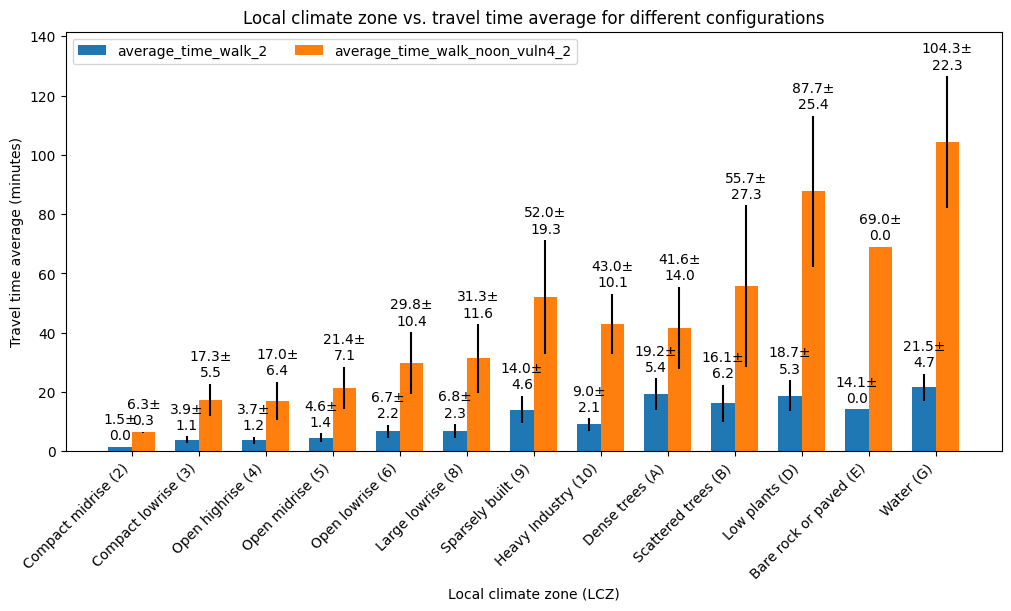

In [15]:
n_s = {configuration: gdf_hexagons_by_lcz[configuration]["mean"] for configuration in configurations}
standard_deviations = {configuration: gdf_hexagons_by_lcz[configuration]["std"] for configuration in configurations}

num_lcz = len(next(iter(n_s.values())))
x = np.arange(num_lcz) * 2
width = 0.7
multiplier = 0

fig, ax = plt.subplots(layout="constrained", figsize=(10, 6))

max_value = 0

for attribute, measurement in n_s.items():
    measurement = np.round(measurement.values, 1)
    y_errs = np.array(standard_deviations[attribute].values) / 2

    max_value = max(max_value, max(measurement + y_errs))
    offset = width * multiplier

    rects = ax.bar(x + offset, measurement, width, label=attribute, yerr=y_errs)
    ax.bar_label(
        rects,
        labels=[f"{val:.1f}±\n{err:.1f}" for val, err in zip(measurement, y_errs)],
        padding=3,
    )

    multiplier += 1

ax.set_ylabel("Travel time average (minutes)")
ax.set_xlabel("Local climate zone (LCZ)")
ax.set_title("Local climate zone vs. travel time average for different configurations")

lcz_labels = gdf_hexagons_by_lcz["lcz"]
ax.set_xticks(x + width * (multiplier - 1) / 2, lcz_labels, rotation=45, ha="right")

ax.legend(loc="upper left", ncols=2)
ax.set_ylim(0, max_value + 15)

plt.show()

<Axes: >

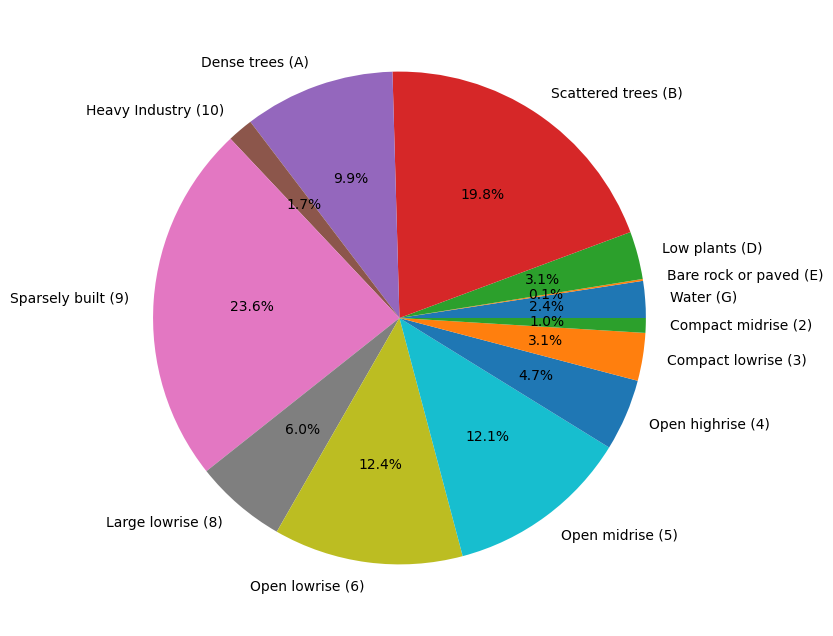

In [16]:
gdf_lcz.groupby("lcz").count().sort_index(key=lambda x: [correct_sequence.index(label) for label in x], ascending=False).plot(y="lcz_class", kind="pie", legend=False, autopct="%1.1f%%", figsize=(8, 8))

In [17]:
gdf_lcz.explore("lcz", legend=True, tooltip=["lcz"])

<Axes: >

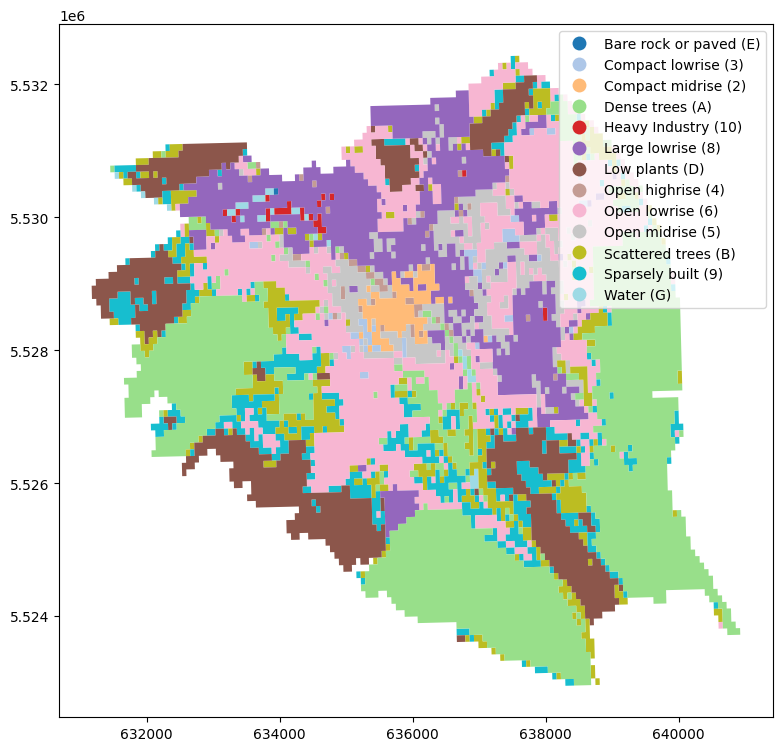

In [18]:
gdf_lcz.plot(column="lcz", legend=True,  figsize=(10, 9), cmap="tab20")